# Ingeniería del Dato: BASE 2 - María Duque Laredo

## Carga de librerías

In [108]:
import pandas as pd
from pathlib import Path

import pandas as pd 
from functools import reduce

import seaborn as sns

import matplotlib.pyplot as plt

import seaborn as sns

## Dataset 1: Gasto en educación por CCAA

In [38]:
# Carga del dataset 1: Gasto en educación por CCAA (INE)

gasto_educacion = pd.read_csv("../raw/gasto_hogares_educacion.csv", 
                         sep="\t", 
                         encoding="latin-1")

# Renombramos las columnas
gasto_educacion = gasto_educacion.rename(columns={
    "Comunidades y ciudades autónomas": "ccaa",
    "Tipo de gasto": "tipo_gasto",
    "Indicador": "indicador",
    "Total": "gasto_reglado_medio"
})

# De la variable 'ccaa' eliminamos la fila de 'Total nacional'

gasto_educacion = gasto_educacion[
    ~gasto_educacion['ccaa'].str.contains("Total", case=False)
]

# Eliminamos la variable 'indicador' porque no nos aporta nada

gasto_educacion = gasto_educacion.drop(columns=["indicador"])

# Normalizamos los nombres de las CCAA

reemplazos = {
    "Asturias, Principado de": "Asturias",
    "Balears, Illes": "Islas Baleares",
    "Castilla - La Mancha": "Castilla La Mancha",
    "Madrid, Comunidad de": "Madrid",
    "Murcia, Región de": "Murcia",
    "Navarra, Comunidad Foral de": "Navarra",
    "Rioja, La": "La Rioja",
    "Comunitat Valenciana": "Comunidad Valenciana",
    "Andalucía": "Andalucia",
    "Aragón": "Aragon",
    "Castilla y León": "Castilla y Leon",
    "País Vasco": "Pais Vasco"

}

gasto_educacion["ccaa"] = gasto_educacion["ccaa"].replace(reemplazos)

# Eliminamos la variable 'tipo_gasto' porque su valor es siempre el mismo 'Gasto en Servicios Educativos reglados'

gasto_educacion = gasto_educacion.drop(columns=['tipo_gasto'])

# Como la variable gasto_reglado_medio esta tipo string y no numérico, lo convertimos                                   

gasto_educacion['gasto_reglado_medio'] = pd.to_numeric(
    gasto_educacion['gasto_reglado_medio']
    .astype(str)
    .str.replace('.', '', regex=False),
    errors='coerce'
)

# Ordenamos el dataset para que se parezca al resto y sea más fácil el merge

gasto_educacion = gasto_educacion.sort_values(by='ccaa').reset_index(drop=True)

# Verificamos que no existen duplicados

print(
    "Duplicados:",
    gasto_educacion.duplicated(
        ["ccaa", "gasto_reglado_medio"]
    ).sum()
)

# Visualizamos el dataset limpio

display(gasto_educacion)

# Guardamos el dataset limpio

gasto_educacion.to_csv(
    "../processed/gasto_hogares_educacion_clean.csv",
    index=False
)

print(gasto_educacion['ccaa'].unique())
print(gasto_educacion.head())
print(gasto_educacion.columns)
print(gasto_educacion.shape)

Duplicados: 0


,ccaa,gasto_reglado_medio
0,Andalucia,1128
1,Aragon,9700
2,Asturias,8950
3,Canarias,1446
4,Cantabria,6800
5,Castilla La Mancha,8610
6,Castilla y Leon,1121
7,Cataluña,1945
8,Ceuta,3980
9,Comunidad Valenciana,1437


<StringArray>
[           'Andalucia',               'Aragon',             'Asturias',
             'Canarias',            'Cantabria',   'Castilla La Mancha',
      'Castilla y Leon',             'Cataluña',                'Ceuta',
 'Comunidad Valenciana',          'Extremadura',              'Galicia',
       'Islas Baleares',             'La Rioja',               'Madrid',
              'Melilla',               'Murcia',              'Navarra',
           'Pais Vasco']
Length: 19, dtype: str
        ccaa  gasto_reglado_medio
0  Andalucia                 1128
1     Aragon                 9700
2   Asturias                 8950
3   Canarias                 1446
4  Cantabria                 6800
Index(['ccaa', 'gasto_reglado_medio'], dtype='str')
(19, 2)


## Dataset 2: Centros educativos por CCAA

In [ ]:
# Carga del dataset 2: Centros educativos por CCAA (EducaBase)

n_centros_ccaa = pd.read_csv("../raw/centros_ccaa.csv", 
                         sep="\t", 
                         encoding="latin-1")

# Renombramos columnas

n_centros_ccaa = n_centros_ccaa.rename(columns={
    "Comunidad autónoma/provincia": "ccaa",
    "Tipo de centro": "tipo_centro",
    "Total": "n_centros"})

# Eliminamos columna 'Titularidad/financiación del centro', no es relevante para este dataset

n_centros_ccaa = n_centros_ccaa.drop(
    columns=["Titularidad/financiación del centro"]
)

# Limpiamos las Comunidades Autónomas
# 1. Eliminamos el código numérico delante de la CCAA

n_centros_ccaa["ccaa"] = n_centros_ccaa["ccaa"].str.replace(
    r"^\d+\s", "", regex=True
)

# 2. Normalizamos los nombres de las CCAA

n_centros_ccaa["ccaa"] = n_centros_ccaa["ccaa"].str.strip()

reemplazos_ccaa = {
    "ANDALUCÍA": "Andalucia",
    "ARAGÓN": "Aragon",
    "ASTURIAS, PRINCIPADO DE": "Asturias",
    "BALEARS, ILLES": "Islas Baleares",
    "CANARIAS": "Canarias",
    "CANTABRIA": "Cantabria",
    "CASTILLA Y LEÓN": "Castilla y Leon",
    "CASTILLA-LA MANCHA": "Castilla La Mancha",
    "CATALUÑA": "Cataluña",
    "COMUNITAT VALENCIANA": "Comunidad Valenciana",
    "EXTREMADURA": "Extremadura",
    "GALICIA": "Galicia",
    "MADRID, COMUNIDAD DE": "Madrid",
    "MURCIA, REGIÓN DE": "Murcia",
    "NAVARRA (Comunidad Foral de) (5)": "Navarra",
    "PAÍS VASCO": "Pais Vasco",
    "RIOJA, LA": "La Rioja",
    "CEUTA": "Ceuta",
    "MELILLA": "Melilla"
}

n_centros_ccaa["ccaa"] = n_centros_ccaa["ccaa"].replace(reemplazos_ccaa)

# Convertimos la variable 'n_centros' a numérica

n_centros_ccaa['n_centros'] = pd.to_numeric(
    n_centros_ccaa['n_centros']
    .astype(str)
    .str.replace('.', '', regex=False),
    errors='coerce'
)

# Eliminamos las filas de la variable 'tipo de centro' cuyo valor sea 'TOTAL'

n_centros_ccaa = n_centros_ccaa[
    n_centros_ccaa["tipo_centro"] != "TOTAL"
]

# Normalizamos los nombres de los tipos de centro

reemplazos_tipo = {
    "Centros E. Primaria (2)": "Centro_primaria",
    "Centros ESO y/o Bachillerato y/o FP (3)": "Centro_secundaria"
}

n_centros_ccaa["tipo_centro"] = n_centros_ccaa["tipo_centro"].replace(reemplazos_tipo)

# Transformamos los datos para pasarlos de formato 'long' (cada ccaa aparece en varias filas) a 'wide'(ccaa solo aparece una vez) pivotando el dataset

df_centros_pivot = n_centros_ccaa.pivot(
    index="ccaa",
    columns="tipo_centro",
    values="n_centros"
).reset_index()

# Eliminamos el nombre del indice 'tipo_centro' de las columnas 

df_centros_pivot.columns.name = None

# Vamos a calcular la proporción de cada tipo de centro por ccaa
# 1. Calculamos el número total de centros considerados por comunidad autónoma

df_centros_pivot["total_centros"] = (
    df_centros_pivot["Centro_primaria"] + df_centros_pivot["Centro_secundaria"]
)

# 2. Creamos variables relativas para evitar que el modelo sesgue por tamaño
# Primaria

df_centros_pivot["pct_centro_primaria"] = (
    df_centros_pivot["Centro_primaria"] / df_centros_pivot["total_centros"]
)

# Secundaria

df_centros_pivot["pct_centro_secundaria"] = (
    df_centros_pivot["Centro_secundaria"] / df_centros_pivot["total_centros"]
)

# Nos quedamos con las variables finales más útiles para el modelo

df_centros_final = df_centros_pivot[
    ["ccaa", "pct_centro_primaria", "pct_centro_secundaria"]
].copy()

# Verificamos que no haya nulos

print(df_centros_final.isnull().sum())

# Verificamos que no existen duplicados

print("Duplicados:", df_centros_final.duplicated(subset=["ccaa"]).sum())

# Visualizamos el dataset final limpio

display(df_centros_final)
print(df_centros_final.info())

# Guardamos el dataset limpio y pivotado

df_centros_final.to_csv(
    "../processed/centros_ccaa_clean.csv",
    index=False
)

ccaa                     0
pct_centro_primaria      0
pct_centro_secundaria    0
dtype: int64
Duplicados: 0


,ccaa,pct_centro_primaria,pct_centro_secundaria
0,Andalucia,0.142857,0.857143
1,Aragon,0.662844,0.337156
2,Asturias,0.668712,0.331288
3,Canarias,0.706564,0.293436
4,Cantabria,0.669767,0.330233
5,Castilla La Mancha,0.710583,0.289417
6,Castilla y Leon,0.680000,0.320000
7,Cataluña,0.182296,0.817704
8,Ceuta,0.708333,0.291667
9,Comunidad Valenciana,0.174560,0.825440


<class 'pandas.DataFrame'>
RangeIndex: 19 entries, 0 to 18
Data columns (total 3 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ccaa                   19 non-null     str    
 1   pct_centro_primaria    19 non-null     float64
 2   pct_centro_secundaria  19 non-null     float64
dtypes: float64(2), str(1)
memory usage: 588.0 bytes
None


## Dataset 3: Graduados de la ESO por tipo de centro y CCAA

In [93]:
# Carga del dataset 3: Graduados de la ESO por tipo de centro y CCAA (EducaBase)

graduados_eso = pd.read_csv("../raw/graduados_eso_centro.csv", 
                         sep="\t", 
                         encoding="latin-1")

# Renombramos columnas

graduados_eso = graduados_eso.rename(columns={
    "Comunidad autónoma/provincia": "ccaa",
    "Tipo de promoción": "tipo_promocion",
    "Sexo": "sexo",
    "Curso": "curso",
    "Titularidad/financiación del centro": "tipo_centro",
    "Total": "pct_promociona_eso"
})

# Eliminamos columna 'tipo_promocion', no es relevante para este dataset

graduados_eso = graduados_eso.drop(
    columns=["tipo_promocion"]
)

# Eliminamos columna 'sexo', no es relevante para este dataset

graduados_eso = graduados_eso.drop(
    columns=["sexo"]
)

# Eliminamos columna 'curso', no es relevante para este dataset

graduados_eso = graduados_eso.drop(
    columns=["curso"]
)

# Limpiamos las Comunidades Autónomas
# 1. Eliminamos el código numérico delante de la CCAA

graduados_eso["ccaa"] = graduados_eso["ccaa"].str.replace(
    r"^\d+\s", "", regex=True
)

# 2. Normalizamos los nombres de las CCAA

graduados_eso["ccaa"] = graduados_eso["ccaa"].str.strip()

reemplazos_ccaa = {
    "ANDALUCÍA": "Andalucia",
    "ARAGÓN": "Aragon",
    "ASTURIAS, PRINCIPADO DE": "Asturias",
    "BALEARS, ILLES": "Islas Baleares",
    "CANARIAS": "Canarias",
    "CANTABRIA": "Cantabria",
    "CASTILLA Y LEÓN": "Castilla y Leon",
    "CASTILLA-LA MANCHA": "Castilla La Mancha",
    "CATALUÑA": "Cataluña",
    "COMUNITAT VALENCIANA": "Comunidad Valenciana",
    "EXTREMADURA": "Extremadura",
    "GALICIA": "Galicia",
    "MADRID, COMUNIDAD DE": "Madrid",
    "MURCIA, REGIÓN DE": "Murcia",
    "NAVARRA, COMUNIDAD FORAL DE": "Navarra",
    "PAÍS VASCO": "Pais Vasco",
    "RIOJA, LA": "La Rioja",
    "CEUTA": "Ceuta",
    "MELILLA": "Melilla"
}

graduados_eso["ccaa"] = graduados_eso["ccaa"].replace(reemplazos_ccaa)

# Convertimos y transformamos la variable 'pct_promociona_eso' a la adecuada

graduados_eso["pct_promociona_eso"] = (
    graduados_eso["pct_promociona_eso"]
    .astype(str)
    .str.replace(",", ".", regex=False)
)

graduados_eso["pct_promociona_eso"] = pd.to_numeric(graduados_eso["pct_promociona_eso"], errors="coerce")

# Normalizamos los valores de la variable 'tipo_centro'

graduados_eso["tipo_centro"] = graduados_eso["tipo_centro"].replace({
    "Centros públicos": "centro_publico",
    "Centros privados": "centro_privado",
    "Centros privados - Ense. concertada": "centro_concertado"
})

# Transformamos los datos para pasarlos de formato 'long' (cada ccaa aparece en varias filas) a 'wide'(ccaa solo aparece una vez) pivotando el dataset

df_eso_pivot = graduados_eso.pivot(
    index="ccaa",
    columns="tipo_centro",
    values="pct_promociona_eso"
).reset_index()

# Renombramos las columnas después de pivotar

df_eso_pivot = df_eso_pivot.rename(columns={
    "centro_publico": "eso_publico",
    "centro_privado": "eso_privado",
    "centro_concertado": "eso_concertado"
})

# Ordenamos el dataset para que tenga el mismo orden que el resto

df_eso_pivot = df_eso_pivot.sort_values("ccaa").reset_index(drop=True)

# Verificamos que no haya nulos

print(df_eso_pivot.isnull().sum())

# Verificamos que no existen duplicados

print("Duplicados:", df_eso_pivot.duplicated(subset=["ccaa"]).sum())

# Visualizamos el dataset final limpio

display(df_eso_pivot)
print(df_eso_pivot.info())

# Guardamos el dataset limpio y pivotado

df_eso_pivot.to_csv(
    "../processed/graduados_eso_centro_clean.csv",
    index=False
)

tipo_centro
ccaa              0
eso_concertado    0
eso_privado       0
eso_publico       0
dtype: int64
Duplicados: 0


tipo_centro,ccaa,eso_concertado,eso_privado,eso_publico
0,Andalucia,92.5,93.2,85.9
1,Aragon,90.5,91.1,87.1
2,Asturias,91.6,92.1,86.6
3,Canarias,95.3,95.9,85.0
4,Cantabria,94.4,94.4,91.3
5,Castilla La Mancha,90.4,91.2,83.9
6,Castilla y Leon,92.6,92.6,85.2
7,Cataluña,93.6,93.8,85.6
8,Ceuta,93.2,93.2,79.0
9,Comunidad Valenciana,92.3,92.7,82.7


<class 'pandas.DataFrame'>
RangeIndex: 19 entries, 0 to 18
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ccaa            19 non-null     str    
 1   eso_concertado  19 non-null     float64
 2   eso_privado     19 non-null     float64
 3   eso_publico     19 non-null     float64
dtypes: float64(3), str(1)
memory usage: 740.0 bytes
None


## Dataset 4: Graduados de Bachillerato por tipo de centro y CCAA

In [15]:
# Carga del dataset 4: Graduados de Bachillerato por tipo de centro y CCAA (EducaBase)

graduados_bach = pd.read_csv("../raw/graduados_bach_centro.csv", 
                         sep="\t", 
                         encoding="latin-1")

# Renombramos las columnas

graduados_bach = graduados_bach.rename(columns={
    "Comunidad autónoma/provincia": "ccaa",
    "Sexo": "sexo",
    "Titularidad del centro": "tipo_centro",
    "Modalidad": "modalidad",
    "Total": "pct_promociona_bach"
})

# Eliminamos columna 'sexo', no es relevante para este dataset

graduados_bach = graduados_bach.drop(
    columns=["sexo"]
)

# Eliminamos columna 'modalidad', no es relevante para este dataset

graduados_bach = graduados_bach.drop(
    columns=["modalidad"]
)

# Limpiamos las Comunidades Autónomas
# 1. Eliminamos el código numérico delante de la CCAA

graduados_bach["ccaa"] = graduados_bach["ccaa"].str.replace(
    r"^\d+\s", "", regex=True
)

# 2. Normalizamos los nombres de las CCAA

graduados_bach["ccaa"] = graduados_bach["ccaa"].str.strip()

reemplazos_ccaa = {
    "ANDALUCÍA": "Andalucia",
    "ARAGÓN": "Aragon",
    "ASTURIAS, PRINCIPADO DE": "Asturias",
    "BALEARS, ILLES": "Islas Baleares",
    "CANARIAS": "Canarias",
    "CANTABRIA": "Cantabria",
    "CASTILLA Y LEÓN": "Castilla y Leon",
    "CASTILLA-LA MANCHA": "Castilla La Mancha",
    "CATALUÑA": "Cataluña",
    "COMUNITAT VALENCIANA": "Comunidad Valenciana",
    "EXTREMADURA": "Extremadura",
    "GALICIA": "Galicia",
    "MADRID, COMUNIDAD DE": "Madrid",
    "MURCIA, REGIÓN DE": "Murcia",
    "NAVARRA, COMUNIDAD FORAL DE": "Navarra",
    "PAÍS VASCO": "Pais Vasco",
    "RIOJA, LA (2)": "La Rioja",
    "CEUTA": "Ceuta",
    "MELILLA": "Melilla"
}

graduados_bach["ccaa"] = graduados_bach["ccaa"].replace(reemplazos_ccaa)

# Convertimos y transformamos la variable 'pct_promociona_bach' a la adecuada

graduados_bach["pct_promociona_bach"] = (
    graduados_bach["pct_promociona_bach"]
    .astype(str)
    .str.replace(",", ".", regex=False)
)

graduados_bach["pct_promociona_bach"] = pd.to_numeric(graduados_bach["pct_promociona_bach"], errors="coerce")

# Normalizamos la variable 'tipo_centro'

graduados_bach["tipo_centro"] = graduados_bach["tipo_centro"].replace({
    "CENTROS PÚBLICOS": "centro_publico",
    "CENTROS PRIVADOS": "centro_privado"
})

# Transformamos los datos para pasarlos de formato 'long' (cada ccaa aparece en varias filas) a 'wide'(ccaa solo aparece una vez) pivotando el dataset

df_bach_pivot = graduados_bach.pivot(
    index="ccaa",
    columns="tipo_centro",
    values="pct_promociona_bach"
).reset_index()

# Renombramos las columnas después de pivotar

df_bach_pivot = df_bach_pivot.rename(columns={
    "centro_publico": "pct_bach_publico",
    "centro_privado": "pct_bach_privado"
})

# Ordenamos el dataset

df_bach_pivot = df_bach_pivot.sort_values("ccaa").reset_index(drop=True)

# Verificamos que no haya nulos

print(df_bach_pivot.isnull().sum())

# Verificamos que no existen duplicados

print("Duplicados:", df_bach_pivot.duplicated(subset=["ccaa"]).sum())

# Visualizamos el dataset final limpio

display(df_bach_pivot)
print(df_bach_pivot.info())

# Guardamos el dataset limpio y pivotado

df_bach_pivot.to_csv(
    "../processed/graduados_bach_centro_clean.csv",
    index=False
)

print(df_bach_pivot.head())

tipo_centro
ccaa                0
pct_bach_privado    0
pct_bach_publico    0
dtype: int64
Duplicados: 0


tipo_centro,ccaa,pct_bach_privado,pct_bach_publico
0,Andalucia,95.3,87.4
1,Aragon,96.9,89.1
2,Asturias,95.5,85.2
3,Canarias,96.3,85.6
4,Cantabria,94.7,89.9
5,Castilla La Mancha,95.6,87.1
6,Castilla y Leon,95.4,85.1
7,Cataluña,96.2,89.4
8,Ceuta,95.7,74.7
9,Comunidad Valenciana,94.6,86.1


<class 'pandas.DataFrame'>
RangeIndex: 19 entries, 0 to 18
Data columns (total 3 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ccaa              19 non-null     str    
 1   pct_bach_privado  19 non-null     float64
 2   pct_bach_publico  19 non-null     float64
dtypes: float64(2), str(1)
memory usage: 588.0 bytes
None
tipo_centro       ccaa  pct_bach_privado  pct_bach_publico
0            Andalucia              95.3              87.4
1               Aragon              96.9              89.1
2             Asturias              95.5              85.2
3             Canarias              96.3              85.6
4            Cantabria              94.7              89.9


## Dataset 5: Graduados FP Básica por centro y CCAA

In [27]:
# Carga del dataset 5: Graduados de FP Básica por tipo de centro y CCAA (EducaBase)

graduados_FPBasica = pd.read_csv("../raw/graduados_FPBasica_centro.csv", 
                         sep="\t", 
                         encoding="latin-1")

# Renombramos las columnas

graduados_FPBasica = graduados_FPBasica.rename(columns={
    "Comunidad autónoma/provincia": "ccaa",
    "Sexo": "sexo",
    "Titularidad del centro": "tipo_centro",
    "Total": "alumnos_fp_basica"
})

# Eliminamos columna 'sexo', no es relevante para este dataset

graduados_FPBasica = graduados_FPBasica.drop(
    columns=["sexo"]
)

# Limpiamos las Comunidades Autónomas
# 1. Eliminamos el código numérico delante de la CCAA

graduados_FPBasica["ccaa"] = graduados_FPBasica["ccaa"].str.replace(
    r"^\d+\s", "", regex=True
)

# 2. Normalizamos los nombres de las CCAA

graduados_FPBasica["ccaa"] = graduados_FPBasica["ccaa"].str.strip()

reemplazos_ccaa = {
    "ANDALUCÍA": "Andalucia",
    "ARAGÓN": "Aragon",
    "ASTURIAS, PRINCIPADO DE": "Asturias",
    "BALEARS, ILLES": "Islas Baleares",
    "CANARIAS": "Canarias",
    "CANTABRIA": "Cantabria",
    "CASTILLA Y LEÓN": "Castilla y Leon",
    "CASTILLA-LA MANCHA": "Castilla La Mancha",
    "CATALUÑA": "Cataluña",
    "COMUNITAT VALENCIANA": "Comunidad Valenciana",
    "EXTREMADURA": "Extremadura",
    "GALICIA": "Galicia",
    "MADRID, COMUNIDAD DE": "Madrid",
    "MURCIA, REGIÓN DE": "Murcia",
    "NAVARRA, COMUNIDAD FORAL DE": "Navarra",
    "PAÍS VASCO": "Pais Vasco",
    "RIOJA, LA": "La Rioja",
    "CEUTA": "Ceuta",
    "MELILLA": "Melilla"
}

graduados_FPBasica["ccaa"] = graduados_FPBasica["ccaa"].replace(reemplazos_ccaa)

# Limpiamos la variable 'alumnos_fp_basica'

graduados_FPBasica["alumnos_fp_basica"] = (
    graduados_FPBasica["alumnos_fp_basica"]
    .astype(str)
    .str.replace(".", "", regex=False)
    .astype(float)
)

# Normalizamos la variable 'tipo_centro'

graduados_FPBasica["tipo_centro"] = graduados_FPBasica["tipo_centro"].replace({
    "CENTROS PÚBLICOS": "centro_publico",
    "CENTROS PRIVADOS": "centro_privado",
    "TODOS LOS CENTROS": "total"
})

# Transformamos los datos para pasarlos de formato 'long' (cada ccaa aparece en varias filas) a 'wide'(ccaa solo aparece una vez) pivotando el dataset

df_fpbasica_pivot = graduados_FPBasica.pivot(
    index="ccaa",
    columns="tipo_centro",
    values="alumnos_fp_basica"
).reset_index()

# Dado que en este dataset no nos dan los % de alumnos graduados sino el número vamos a calcular el porcentaje

df_fpbasica_pivot["pct_fpbasica_publico"] = (
    df_fpbasica_pivot["centro_publico"] / df_fpbasica_pivot["total"]
)

df_fpbasica_pivot["pct_fpbasica_privado"] = (
    df_fpbasica_pivot["centro_privado"] / df_fpbasica_pivot["total"]
)

# Limpiamos el dataset, nos quedamos con las variables que ya son útiles

df_fpbasica_pivot = df_fpbasica_pivot[[
    "ccaa",
    "pct_fpbasica_publico",
    "pct_fpbasica_privado"
]]

# Ordenamos el dataset 

df_fpbasica_pivot = df_fpbasica_pivot.sort_values("ccaa").reset_index(drop=True)

# Verificamos que no haya nulos

print(df_fpbasica_pivot.isnull().sum())

# Verificamos que no existen duplicados

print("Duplicados:", df_fpbasica_pivot.duplicated(subset=["ccaa"]).sum())

# Visualizamos el dataset final limpio

display(df_fpbasica_pivot)
print(df_fpbasica_pivot.info())

# Guardamos el dataset limpio y pivotado

df_fpbasica_pivot.to_csv(
    "../processed/graduados_FPBasica_centro_clean.csv",
    index=False
)

tipo_centro
ccaa                    0
pct_fpbasica_publico    0
pct_fpbasica_privado    0
dtype: int64
Duplicados: 0


tipo_centro,ccaa,pct_fpbasica_publico,pct_fpbasica_privado
0,Andalucia,0.748701,0.251299
1,Aragon,0.691388,0.308612
2,Asturias,0.675676,0.324324
3,Canarias,0.938133,0.061867
4,Cantabria,0.592920,0.407080
5,Castilla La Mancha,0.088213,1.178651
6,Castilla y Leon,6.472125,3.527875
7,Cataluña,1.000000,0.000000
8,Ceuta,0.916667,0.083333
9,Comunidad Valenciana,0.884385,1.156152


<class 'pandas.DataFrame'>
RangeIndex: 19 entries, 0 to 18
Data columns (total 3 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ccaa                  19 non-null     str    
 1   pct_fpbasica_publico  19 non-null     float64
 2   pct_fpbasica_privado  19 non-null     float64
dtypes: float64(2), str(1)
memory usage: 588.0 bytes
None


## Dataset 6: Graduados FP Medio por centro y CCAA

In [46]:
# Carga del dataset 6: Graduados de FP Medio por tipo de centro y CCAA (EducaBase)

graduados_FPMedio = pd.read_csv("../raw/graduados_FPMedio_centro.csv", 
                         sep="\t", 
                         encoding="latin-1")

# Renombramos las columnas

graduados_FPMedio = graduados_FPMedio.rename(columns={
    "Comunidad autónoma/provincia": "ccaa",
    "Sexo": "sexo",
    "Titularidad del centro": "tipo_centro",
    "Total": "alumnos_fp_medio"
})

# Eliminamos columna 'sexo', no es relevante para este dataset

graduados_FPMedio = graduados_FPMedio.drop(
    columns=["sexo"]
)

# Limpiamos las Comunidades Autónomas
# 1. Eliminamos el código numérico delante de la CCAA

graduados_FPMedio["ccaa"] = graduados_FPMedio["ccaa"].str.replace(
    r"^\d+\s", "", regex=True
)

# 2. Normalizamos los nombres de las CCAA

graduados_FPMedio["ccaa"] = graduados_FPMedio["ccaa"].str.strip()

reemplazos_ccaa = {
    "ANDALUCÍA": "Andalucia",
    "ARAGÓN": "Aragon",
    "ASTURIAS, PRINCIPADO DE": "Asturias",
    "BALEARS, ILLES": "Islas Baleares",
    "CANARIAS": "Canarias",
    "CANTABRIA": "Cantabria",
    "CASTILLA Y LEÓN": "Castilla y Leon",
    "CASTILLA-LA MANCHA": "Castilla La Mancha",
    "CATALUÑA": "Cataluña",
    "COMUNITAT VALENCIANA": "Comunidad Valenciana",
    "EXTREMADURA": "Extremadura",
    "GALICIA": "Galicia",
    "MADRID, COMUNIDAD DE": "Madrid",
    "MURCIA, REGIÓN DE": "Murcia",
    "NAVARRA, COMUNIDAD FORAL DE": "Navarra",
    "PAÍS VASCO": "Pais Vasco",
    "RIOJA, LA": "La Rioja",
    "CEUTA": "Ceuta",
    "MELILLA": "Melilla"
}

graduados_FPMedio["ccaa"] = graduados_FPMedio["ccaa"].replace(reemplazos_ccaa)

# Limpiamos la variable 'alumnos_fp_medio'

graduados_FPMedio["alumnos_fp_medio"] = (
    graduados_FPMedio["alumnos_fp_medio"]
    .astype(str)
    .str.replace(".", "", regex=False)
    .astype(float)
)

# Normalizamos la variable 'tipo_centro'

graduados_FPMedio["tipo_centro"] = graduados_FPMedio["tipo_centro"].replace({
    "CENTROS PÚBLICOS": "centro_publico",
    "CENTROS PRIVADOS": "centro_privado",
    "TODOS LOS CENTROS": "total"
})

# Transformamos los datos para pasarlos de formato 'long' (cada ccaa aparece en varias filas) a 'wide'(ccaa solo aparece una vez) pivotando el dataset

df_fpmedio_pivot = graduados_FPMedio.pivot(
    index="ccaa",
    columns="tipo_centro",
    values="alumnos_fp_medio"
).reset_index()

# Dado que en este dataset no nos dan los % de alumnos graduados sino el número vamos a calcular el porcentaje

df_fpmedio_pivot["pct_fpmedio_publico"] = (
    df_fpmedio_pivot["centro_publico"] / df_fpmedio_pivot["total"]
)

df_fpmedio_pivot["pct_fpmedio_privado"] = (
    df_fpmedio_pivot["centro_privado"] / df_fpmedio_pivot["total"]
)

# Limpiamos el dataset, nos quedamos con las variables que ya son útiles

df_fpmedio_pivot = df_fpmedio_pivot[[
    "ccaa",
    "pct_fpmedio_publico",
    "pct_fpmedio_privado"
]]

# Ordenamos el dataset 

df_fpmedio_pivot = df_fpmedio_pivot.sort_values("ccaa").reset_index(drop=True)

# Verificamos que no haya nulos

print(df_fpmedio_pivot.isnull().sum())

# Verificamos que no existen duplicados

print("Duplicados:", df_fpmedio_pivot.duplicated(subset=["ccaa"]).sum())

# Visualizamos el dataset final limpio

display(df_fpmedio_pivot)
print(df_fpmedio_pivot.info())

# Guardamos el dataset limpio y pivotado

df_fpmedio_pivot.to_csv(
    "../processed/graduados_FPMedio_centro_clean.csv",
    index=False
)

tipo_centro
ccaa                   0
pct_fpmedio_publico    0
pct_fpmedio_privado    0
dtype: int64
Duplicados: 0


tipo_centro,ccaa,pct_fpmedio_publico,pct_fpmedio_privado
0,Andalucia,0.611386,0.388614
1,Aragon,0.640554,0.359446
2,Asturias,0.670467,3.295331
3,Canarias,0.911922,0.880776
4,Cantabria,0.668857,3.311432
5,Castilla La Mancha,0.766401,0.233599
6,Castilla y Leon,6.622642,3.377358
7,Cataluña,0.691368,0.308632
8,Ceuta,1.000000,0.000000
9,Comunidad Valenciana,0.666828,0.033317


<class 'pandas.DataFrame'>
RangeIndex: 19 entries, 0 to 18
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ccaa                 19 non-null     str    
 1   pct_fpmedio_publico  19 non-null     float64
 2   pct_fpmedio_privado  19 non-null     float64
dtypes: float64(2), str(1)
memory usage: 588.0 bytes
None


## Dataset 7: Graduados FP Superior por centro y CCAA

In [73]:
# Carga del dataset 7: Graduados de FP Superior por tipo de centro y CCAA (EducaBase)

graduados_FPSuperior = pd.read_csv(
    "../raw/graduados_FPSuperior_centro.csv",
    sep="\t",
    encoding="latin-1"
)

# Renombramos las columnas

graduados_FPSuperior = graduados_FPSuperior.rename(columns={
    "Comunidad autónoma/provincia": "ccaa",
    "Sexo": "sexo",
    "Titularidad del centro": "tipo_centro",
    "Total": "alumnos_fp_superior"
})

# Eliminamos columna 'sexo', no es relevante para este dataset

graduados_FPSuperior = graduados_FPSuperior.drop(
    columns=["sexo"]
)

# Limpiamos las Comunidades Autónomas
# 1. Eliminamos el código numérico delante de la CCAA

graduados_FPSuperior["ccaa"] = graduados_FPSuperior["ccaa"].str.replace(
    r"^\d+\s", "", regex=True
)

# 2. Normalizamos los nombres de las CCAA

graduados_FPSuperior["ccaa"] = graduados_FPSuperior["ccaa"].str.strip()

reemplazos_ccaa = {
    "ANDALUCÍA": "Andalucia",
    "ARAGÓN": "Aragon",
    "ASTURIAS, PRINCIPADO DE": "Asturias",
    "BALEARS, ILLES": "Islas Baleares",
    "CANARIAS": "Canarias",
    "CANTABRIA": "Cantabria",
    "CASTILLA Y LEÓN": "Castilla y Leon",
    "CASTILLA-LA MANCHA": "Castilla La Mancha",
    "CATALUÑA": "Cataluña",
    "COMUNITAT VALENCIANA": "Comunidad Valenciana",
    "EXTREMADURA": "Extremadura",
    "GALICIA": "Galicia",
    "MADRID, COMUNIDAD DE": "Madrid",
    "MURCIA, REGIÓN DE": "Murcia",
    "NAVARRA, COMUNIDAD FORAL DE": "Navarra",
    "PAÍS VASCO": "Pais Vasco",
    "RIOJA, LA": "La Rioja",
    "CEUTA": "Ceuta",
    "MELILLA": "Melilla"
}

graduados_FPSuperior["ccaa"] = graduados_FPSuperior["ccaa"].replace(reemplazos_ccaa)

# Limpiamos la variable 'alumnos_fp_superior'

graduados_FPSuperior["alumnos_fp_superior"] = (
    graduados_FPSuperior["alumnos_fp_superior"]
    .astype(str)
    .str.replace(".", "", regex=False)
    .astype(float)
)

# Normalizamos la variable 'tipo_centro'

graduados_FPSuperior["tipo_centro"] = graduados_FPSuperior["tipo_centro"].replace({
    "CENTROS PÚBLICOS": "centro_publico",
    "CENTROS PRIVADOS": "centro_privado",
    "TODOS LOS CENTROS": "total"
})

# Transformamos los datos para pasarlos de formato 'long' (cada ccaa aparece en varias filas) a 'wide'(ccaa solo aparece una vez) pivotando el dataset

df_fpsuperior_pivot = graduados_FPSuperior.pivot(
    index="ccaa",
    columns="tipo_centro",
    values="alumnos_fp_superior"
).reset_index()

# Dado que en este dataset no nos dan los % de alumnos graduados sino el número vamos a calcular el porcentaje

df_fpsuperior_pivot["pct_fpsuperior_publico"] = (
    df_fpsuperior_pivot["centro_publico"] / df_fpsuperior_pivot["total"]
)

df_fpsuperior_pivot["pct_fpsuperior_privado"] = (
    df_fpsuperior_pivot["centro_privado"] / df_fpsuperior_pivot["total"]
)

# Limpiamos el dataset, nos quedamos con las variables que ya son útiles

df_fpsuperior_pivot = df_fpsuperior_pivot[[
    "ccaa",
    "pct_fpsuperior_publico",
    "pct_fpsuperior_privado"
]]

# Ordenamos el dataset 

df_fpsuperior_pivot = df_fpsuperior_pivot.sort_values("ccaa").reset_index(drop=True)

# Verificamos que no haya nulos

print(df_fpsuperior_pivot.isnull().sum())

# Verificamos que no existen duplicados

print("Duplicados:", df_fpsuperior_pivot.duplicated(subset=["ccaa"]).sum())

# Visualizamos el dataset final limpio

display(df_fpsuperior_pivot)
print(df_fpsuperior_pivot.info())

# Guardamos el dataset limpio y pivotado

df_fpsuperior_pivot.to_csv(
    "../processed/graduados_FPSuperior_centro_clean.csv",
    index=False
)

print(df_fpsuperior_pivot.head())

tipo_centro
ccaa                      0
pct_fpsuperior_publico    0
pct_fpsuperior_privado    0
dtype: int64
Duplicados: 0


tipo_centro,ccaa,pct_fpsuperior_publico,pct_fpsuperior_privado
0,Andalucia,0.593634,0.406366
1,Aragon,0.585604,0.414396
2,Asturias,0.745611,2.543894
3,Canarias,0.869347,1.306533
4,Cantabria,0.705781,2.942187
5,Castilla La Mancha,0.853841,1.461592
6,Castilla y Leon,0.716542,0.283458
7,Cataluña,0.062148,0.378524
8,Ceuta,1.000000,0.000000
9,Comunidad Valenciana,0.680974,0.031903


<class 'pandas.DataFrame'>
RangeIndex: 19 entries, 0 to 18
Data columns (total 3 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ccaa                    19 non-null     str    
 1   pct_fpsuperior_publico  19 non-null     float64
 2   pct_fpsuperior_privado  19 non-null     float64
dtypes: float64(2), str(1)
memory usage: 588.0 bytes
None
tipo_centro       ccaa  pct_fpsuperior_publico  pct_fpsuperior_privado
0            Andalucia                0.593634                0.406366
1               Aragon                0.585604                0.414396
2             Asturias                0.745611                2.543894
3             Canarias                0.869347                1.306533
4            Cantabria                0.705781                2.942187


## Dataset 8: Renta per cápita por CCAA - Preparar para el merge

In [81]:
# Carga del dataset 8: Renta per cápita por CCAA ya la teníamos limpia, ahora la vamos a preparar para el merge

renta_ccaa = pd.read_csv(
    "../processed/renta_ccaa_clean.csv"
)

# Filtramos únicamente el año 2023 para mantener coherencia temporal con el resto de variables del modelo de clustering

renta_ccaa = renta_ccaa[renta_ccaa["year"] == 2023].copy()

# Limpiamos el dataset para quedarnos solo con las variables necesarias para el merge final

renta_ccaa = renta_ccaa[["ccaa", "renta_pc"]].copy()

# Renombramos la variable 'renta_pc' para que quede más clara

renta_ccaa = renta_ccaa.rename(columns={
    "renta_pc": "renta_per_capita"
})

# Mofdificamos una comunidad autónoma para que este escrita igual que el resto de dataset y en el merge no haya problemas

renta_ccaa["ccaa"] = renta_ccaa["ccaa"].replace({
    "Castilla - La Mancha": "Castilla La Mancha"
})

# Verificamos que no haya nulos

print(renta_ccaa.isnull().sum())

# Verificamos que no existen duplicados

print("Duplicados:", renta_ccaa.duplicated(subset=["ccaa"]).sum())

# Visualizamos el dataset final limpio

display(renta_ccaa)
print(renta_ccaa.info())

# Guardamos el dataset limpio y pivotado

renta_ccaa.to_csv(
    "../processed/rentapercapita2_ccaa_clean.csv",
    index=False
)

ccaa                0
renta_per_capita    0
dtype: int64
Duplicados: 0


,ccaa,renta_per_capita
4,Andalucia,11.719
11,Aragon,14.810
18,Asturias,15.432
25,Canarias,12.177
32,Cantabria,14.162
39,Castilla La Mancha,11.913
46,Castilla y Leon,14.124
53,Cataluña,15.830
60,Ceuta,13.421
67,Comunidad Valenciana,12.805


<class 'pandas.DataFrame'>
RangeIndex: 19 entries, 4 to 130
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ccaa              19 non-null     str    
 1   renta_per_capita  19 non-null     float64
dtypes: float64(1), str(1)
memory usage: 436.0 bytes
None


## **BASE FINAL 2**

In [ ]:
# Primero cargamos todas los dataset para comprobar que tienen la misma estructura y no se nos ha escapado nada

gasto = pd.read_csv("../processed/gasto_hogares_educacion_clean.csv")
centros = pd.read_csv("../processed/centros_ccaa_clean.csv")
eso = pd.read_csv("../processed/graduados_eso_centro_clean.csv")
bach = pd.read_csv("../processed/graduados_bach_centro_clean.csv")
fp_basica = pd.read_csv("../processed/graduados_FPBasica_centro_clean.csv")
fp_medio = pd.read_csv("../processed/graduados_FPMedio_centro_clean.csv")
fp_superior = pd.read_csv("../processed/graduados_FPSuperior_centro_clean.csv")
renta = pd.read_csv("../processed/rentapercapita2_ccaa_clean.csv")

# Comprobamos que todos los valores de las comunidades autónomas esten normalizados correctamente

print(sorted(centros["ccaa"].unique()))
print(sorted(gasto["ccaa"].unique()))
print(sorted(eso["ccaa"].unique()))
print(sorted(bach["ccaa"].unique()))
print(sorted(fp_basica["ccaa"].unique()))
print(sorted(fp_medio["ccaa"].unique()))
print(sorted(fp_superior["ccaa"].unique()))
print(sorted(renta["ccaa"].unique()))

# Realizamos el merge de todas las bases de datos ya limpias y transformadas mediante la clave común 'ccaa'
# El objetivo de esta base de datos final es convertirla en una única matriz de datos lista para el modelo de clustering
# Vamos a hacer un merge tipo left para conservar todas las comunidades autónomas

BaseFinal2 = centros.merge(gasto, on="ccaa", how="left")
BaseFinal2 = BaseFinal2.merge(eso, on="ccaa", how="left")
BaseFinal2 = BaseFinal2.merge(bach, on="ccaa", how="left")
BaseFinal2 = BaseFinal2.merge(fp_basica, on="ccaa", how="left")
BaseFinal2 = BaseFinal2.merge(fp_medio, on="ccaa", how="left")
BaseFinal2 = BaseFinal2.merge(fp_superior, on="ccaa", how="left")
BaseFinal2 = BaseFinal2.merge(renta, on="ccaa", how="left")

# Tenemos variables que son porcentajes pero con distintas escalas, vamos a homogeneizar los porcentajes

cols_pct = [
    "pct_fpbasica_publico",
    "pct_fpbasica_privado",
    "pct_fpmedio_publico",
    "pct_fpmedio_privado",
    "pct_fpsuperior_publico",
    "pct_fpsuperior_privado",
    "pct_centro_primaria",
    "pct_centro_secundaria"
]

BaseFinal2[cols_pct] = BaseFinal2[cols_pct] * 100

# Homogeneizamos las variables que no son porcentajes para que a la hora de hacer el modelo no suponga un problema

BaseFinal2["renta_per_capita"] = BaseFinal2["renta_per_capita"] * 1000
BaseFinal2["renta_per_capita"] = BaseFinal2["renta_per_capita"].astype(int)

# Ordenamos el dataset para que tenga una estructura lo más clara posible

BaseFinal2 = BaseFinal2.sort_values("ccaa").reset_index(drop=True)

# Comprobamos la estructura del dataset

print("Dimensiones de la base final 2:", BaseFinal2.shape)

# Verificamos que no se haya creado ningún duplicado después del merge

print("Duplicados en la base final 2:", BaseFinal2.duplicated(subset=["ccaa"]).sum())

# Detectamos valores nulos y sus porcentajes

porcentaje_nulos = (BaseFinal2.isnull().sum() / len(BaseFinal2)) * 100
print("Porcentaje de nulos por variable:")

tabla_nulos = pd.DataFrame({
    "n_nulos": BaseFinal2.isnull().sum(),
    "%_nulos": porcentaje_nulos
}).sort_values(by="%_nulos", ascending=False)

display(tabla_nulos)

# Visualizamos el dataset final limpio

display(BaseFinal2)
print(BaseFinal2.info())

# Guardamos la Base Final 1 

BaseFinal2.to_csv("../processed/BaseFinal2_clean.csv", index=False)

['Andalucia', 'Aragon', 'Asturias', 'Canarias', 'Cantabria', 'Castilla La Mancha', 'Castilla y Leon', 'Cataluña', 'Ceuta', 'Comunidad Valenciana', 'Extremadura', 'Galicia', 'Islas Baleares', 'La Rioja', 'Madrid', 'Melilla', 'Murcia', 'Navarra', 'Pais Vasco']
['Andalucia', 'Aragon', 'Asturias', 'Canarias', 'Cantabria', 'Castilla La Mancha', 'Castilla y Leon', 'Cataluña', 'Ceuta', 'Comunidad Valenciana', 'Extremadura', 'Galicia', 'Islas Baleares', 'La Rioja', 'Madrid', 'Melilla', 'Murcia', 'Navarra', 'Pais Vasco']
['Andalucia', 'Aragon', 'Asturias', 'Canarias', 'Cantabria', 'Castilla La Mancha', 'Castilla y Leon', 'Cataluña', 'Ceuta', 'Comunidad Valenciana', 'Extremadura', 'Galicia', 'Islas Baleares', 'La Rioja', 'Madrid', 'Melilla', 'Murcia', 'Navarra', 'Pais Vasco']
['Andalucia', 'Aragon', 'Asturias', 'Canarias', 'Cantabria', 'Castilla La Mancha', 'Castilla y Leon', 'Cataluña', 'Ceuta', 'Comunidad Valenciana', 'Extremadura', 'Galicia', 'Islas Baleares', 'La Rioja', 'Madrid', 'Melilla',

,n_nulos,%_nulos
ccaa,0,0.0
pct_centro_primaria,0,0.0
pct_centro_secundaria,0,0.0
gasto_reglado_medio,0,0.0
eso_concertado,0,0.0
eso_privado,0,0.0
eso_publico,0,0.0
pct_bach_privado,0,0.0
pct_bach_publico,0,0.0
pct_fpbasica_publico,0,0.0


,ccaa,pct_centro_primaria,pct_centro_secundaria,gasto_reglado_medio,eso_concertado,eso_privado,eso_publico,pct_bach_privado,pct_bach_publico,pct_fpbasica_publico,pct_fpbasica_privado,pct_fpmedio_publico,pct_fpmedio_privado,pct_fpsuperior_publico,pct_fpsuperior_privado,renta_per_capita
0,Andalucia,14.285714,85.714286,1128,92.5,93.2,85.9,95.3,87.4,74.870056,25.129944,61.138573,38.861427,59.363410,40.636590,11719
1,Aragon,66.284404,33.715596,9700,90.5,91.1,87.1,96.9,89.1,69.138756,30.861244,64.055438,35.944562,58.560360,41.439640,14810
2,Asturias,66.871166,33.128834,8950,91.6,92.1,86.6,95.5,85.2,67.567568,32.432432,67.046688,329.533116,74.561061,254.389387,15432
3,Canarias,70.656371,29.343629,1446,95.3,95.9,85.0,96.3,85.6,93.813273,6.186727,91.192239,88.077610,86.934673,130.653266,12177
4,Cantabria,66.976744,33.023256,6800,94.4,94.4,91.3,94.7,89.9,59.292035,40.707965,66.885677,331.143233,70.578134,294.218661,14162
5,Castilla La Mancha,71.058315,28.941685,8610,90.4,91.2,83.9,95.6,87.1,8.821349,117.865085,76.640121,23.359879,85.384081,146.159194,11913
6,Castilla y Leon,68.000000,32.000000,1121,92.6,92.6,85.2,95.4,85.1,647.212544,352.787456,662.264151,337.735849,71.654212,28.345788,14124
7,Cataluña,18.229557,81.770443,1945,93.6,93.8,85.6,96.2,89.4,100.000000,0.000000,69.136812,30.863188,6.214762,37.852378,15830
8,Ceuta,70.833333,29.166667,3980,93.2,93.2,79.0,95.7,74.7,91.666667,8.333333,100.000000,0.000000,100.000000,0.000000,13421
9,Comunidad Valenciana,17.456022,82.543978,1437,92.3,92.7,82.7,94.6,86.1,88.438481,115.615187,66.682762,3.331724,68.097416,3.190258,12805


<class 'pandas.DataFrame'>
RangeIndex: 19 entries, 0 to 18
Data columns (total 16 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ccaa                    19 non-null     str    
 1   pct_centro_primaria     19 non-null     float64
 2   pct_centro_secundaria   19 non-null     float64
 3   gasto_reglado_medio     19 non-null     int64  
 4   eso_concertado          19 non-null     float64
 5   eso_privado             19 non-null     float64
 6   eso_publico             19 non-null     float64
 7   pct_bach_privado        19 non-null     float64
 8   pct_bach_publico        19 non-null     float64
 9   pct_fpbasica_publico    19 non-null     float64
 10  pct_fpbasica_privado    19 non-null     float64
 11  pct_fpmedio_publico     19 non-null     float64
 12  pct_fpmedio_privado     19 non-null     float64
 13  pct_fpsuperior_publico  19 non-null     float64
 14  pct_fpsuperior_privado  19 non-null     float64
 15  re

## **ANÁLISIS DESCRIPTIVO Y EXPLORATORIO DE BASE FINAL 2**

Dimensiones: (19, 16)
Duplicados: 0


,count,mean,std,min,25%,50%,75%,max,mediana,varianza
pct_centro_primaria,19.0,59.277437,19.442172,14.285714,62.836351,66.976744,70.405108,73.033708,66.976744,3.779981e+02
pct_centro_secundaria,19.0,40.722563,19.442172,26.966292,29.594892,33.023256,37.163649,85.714286,33.023256,3.779981e+02
gasto_reglado_medio,19.0,4030.578947,3374.206068,179.000000,1431.500000,1945.000000,7310.000000,9700.000000,1945.000000,1.138527e+07
eso_concertado,19.0,92.905263,1.938635,89.900000,91.650000,92.600000,94.250000,97.600000,92.600000,3.758304e+00
eso_privado,19.0,93.300000,1.719819,90.300000,92.500000,93.200000,94.200000,97.600000,93.200000,2.957778e+00
eso_publico,19.0,85.642105,3.561416,79.000000,83.450000,85.200000,87.400000,93.500000,85.200000,1.268368e+01
pct_bach_privado,19.0,94.863158,1.930806,89.100000,94.650000,95.400000,95.950000,96.900000,95.400000,3.728012e+00
pct_bach_publico,19.0,86.463158,3.817243,74.700000,85.350000,86.900000,89.100000,93.200000,86.900000,1.457135e+01
pct_fpbasica_publico,19.0,114.247134,142.737733,8.209483,65.890807,79.749104,96.677978,647.212544,79.749104,2.037406e+04
pct_fpbasica_privado,19.0,114.879901,172.746429,0.000000,14.292115,35.785953,148.458374,688.100517,35.785953,2.984133e+04


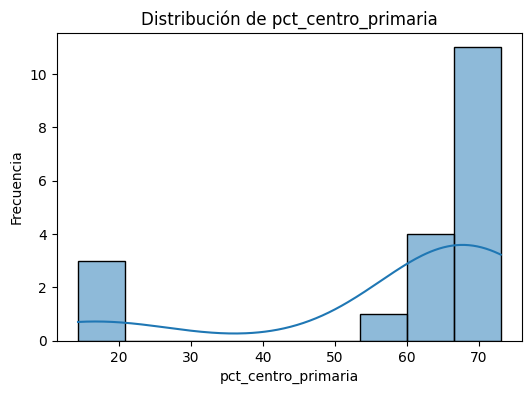

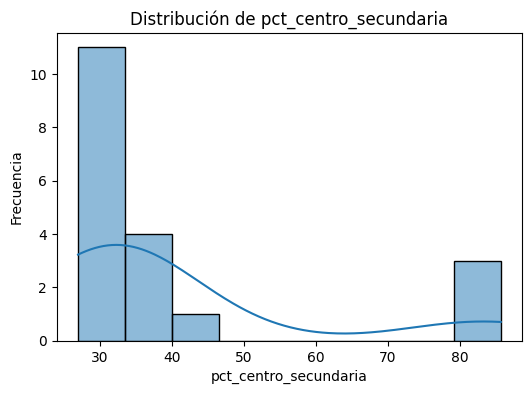

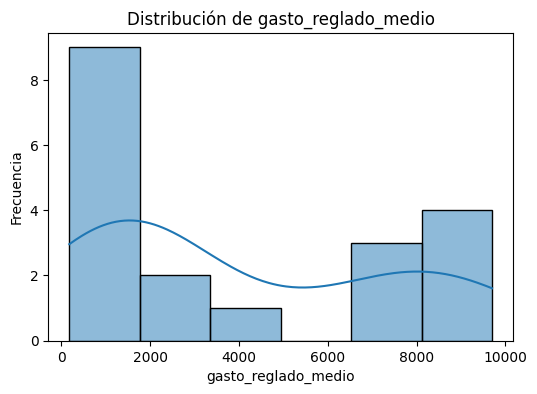

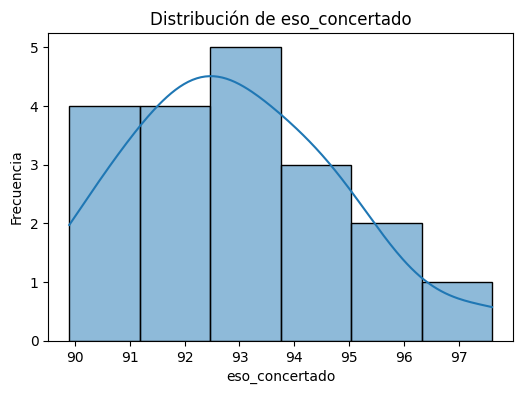

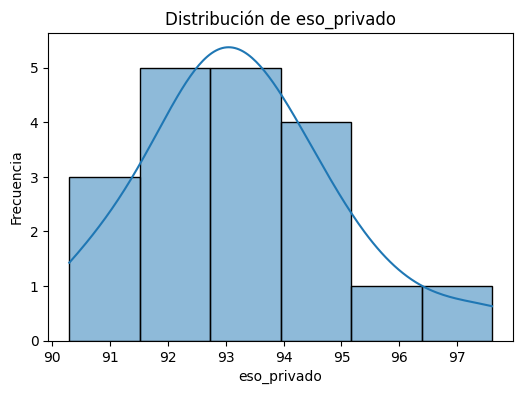

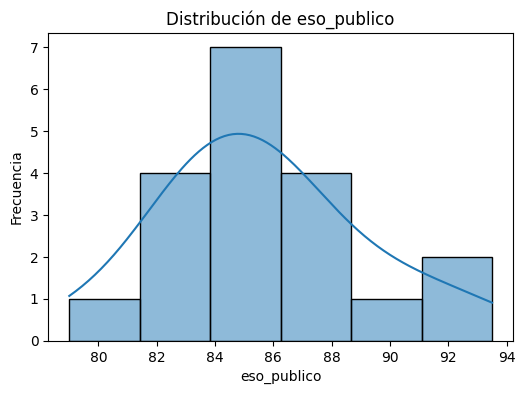

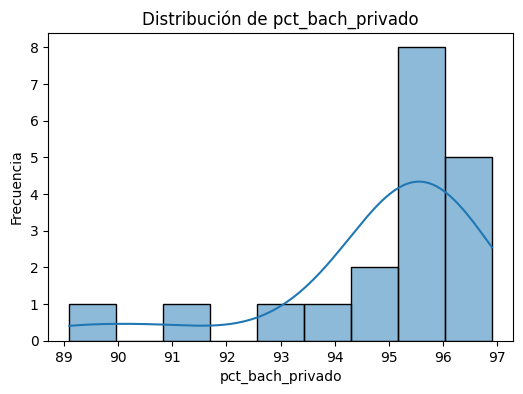

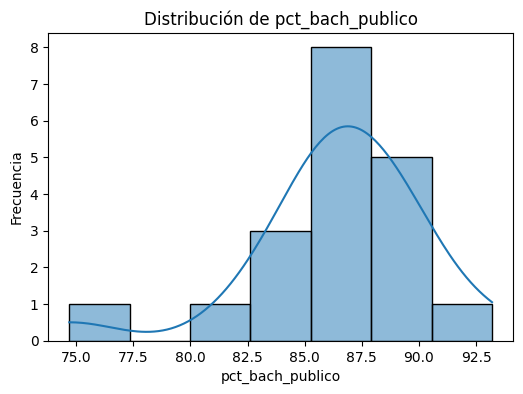

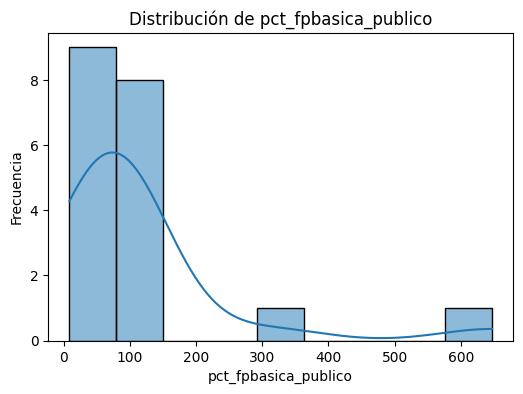

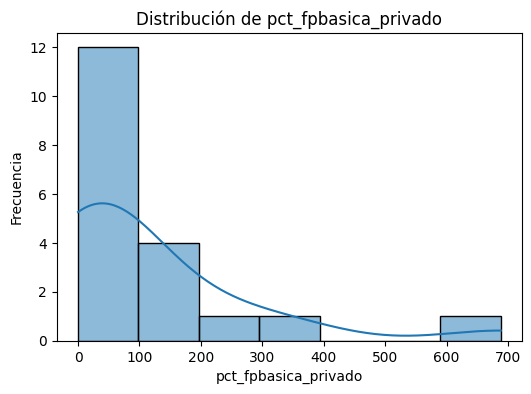

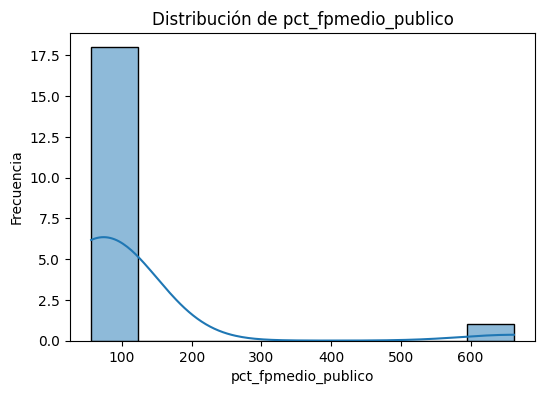

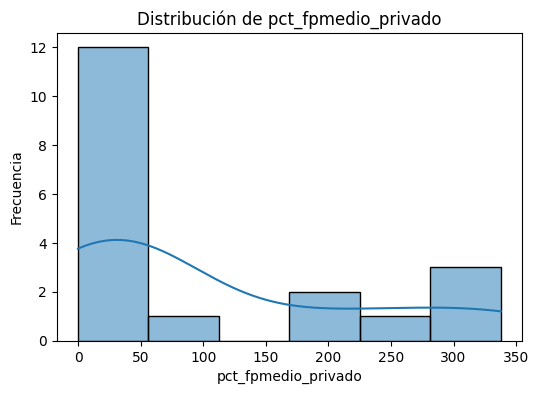

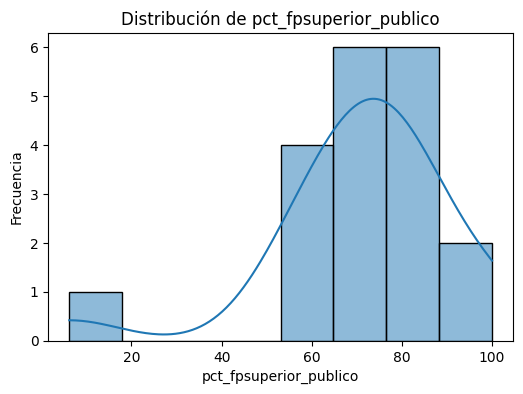

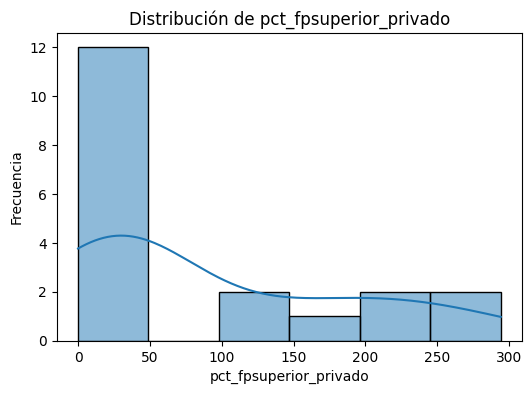

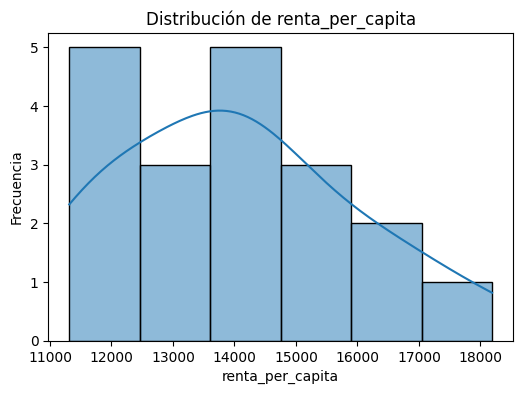

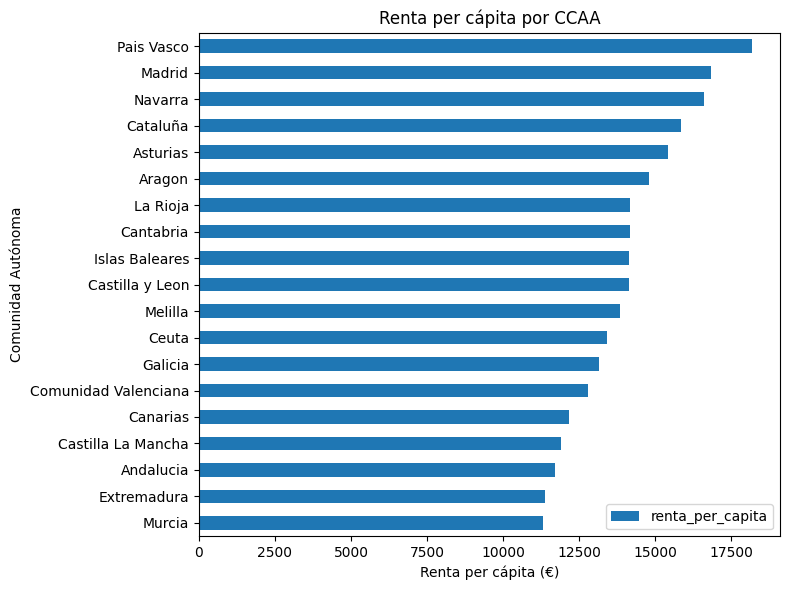

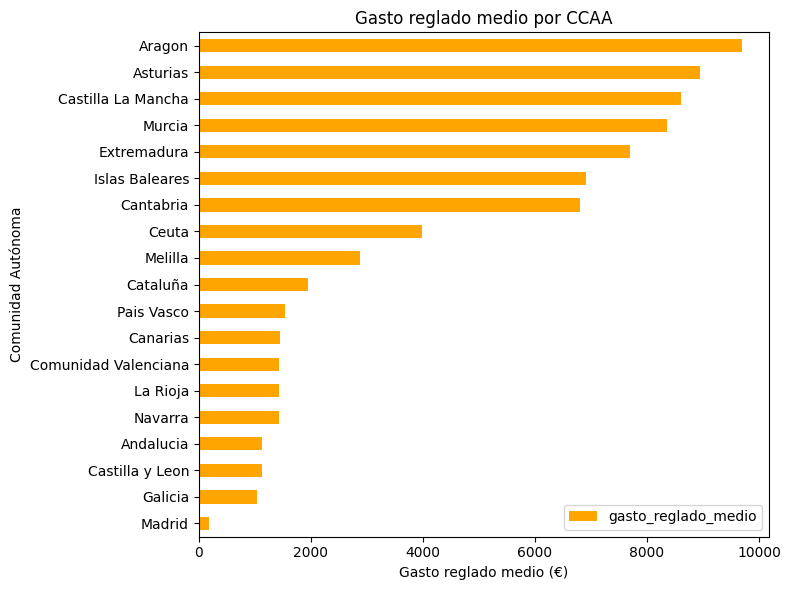

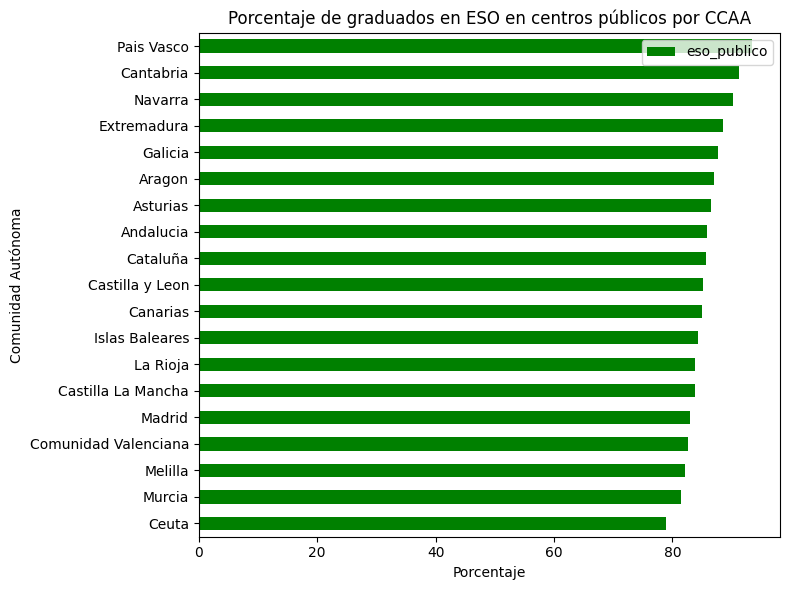

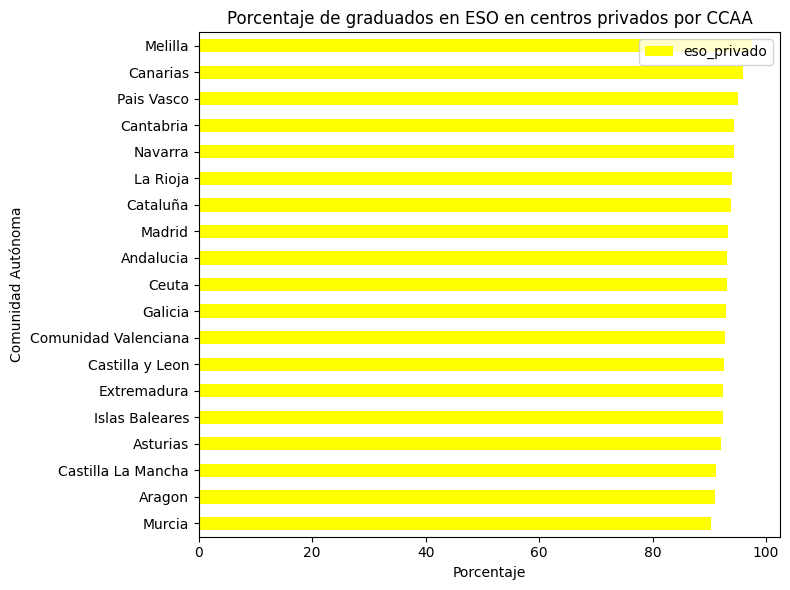

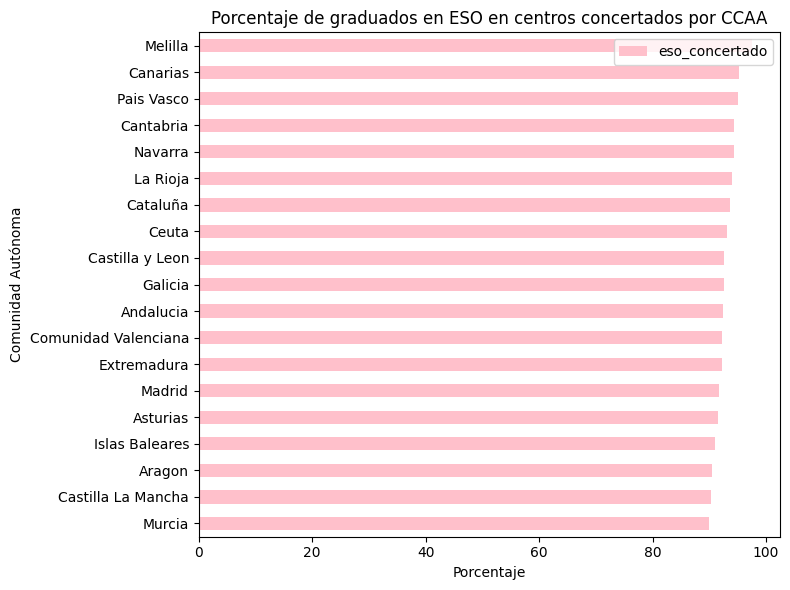

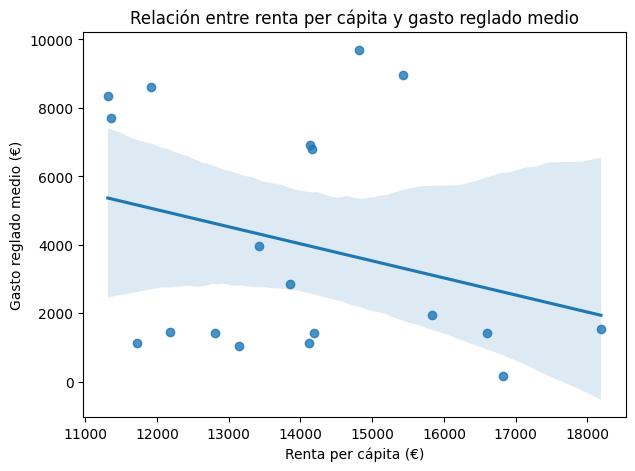

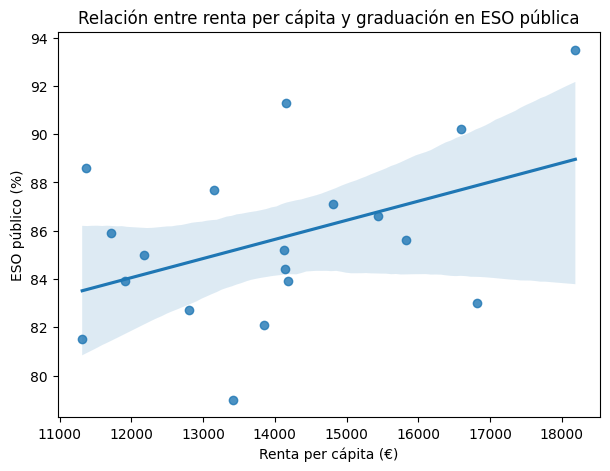

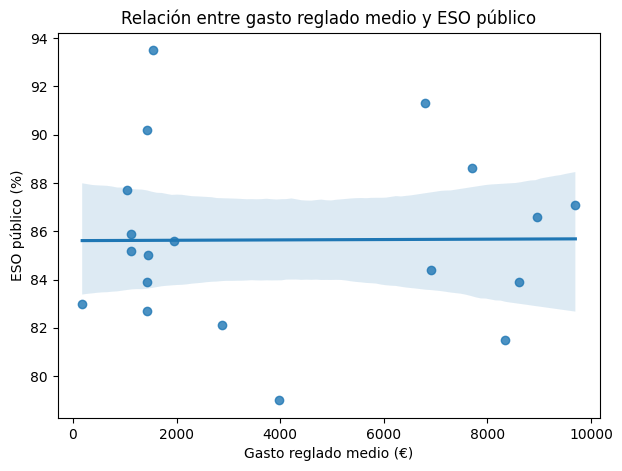

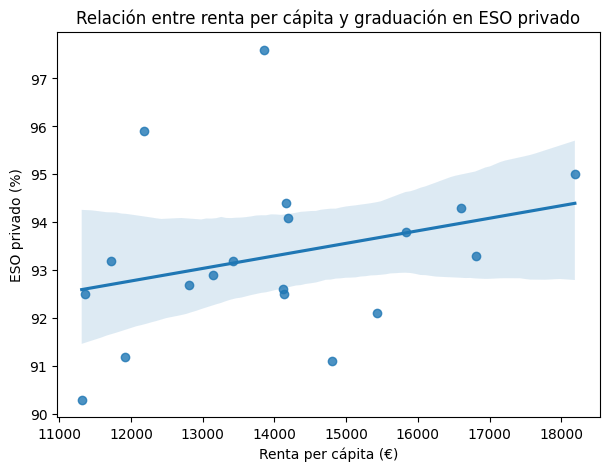

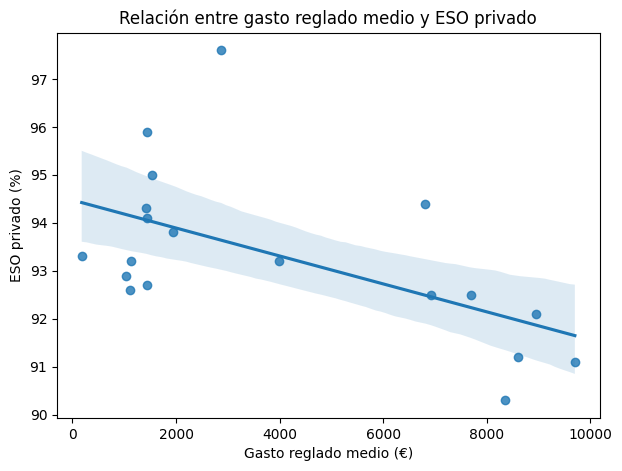

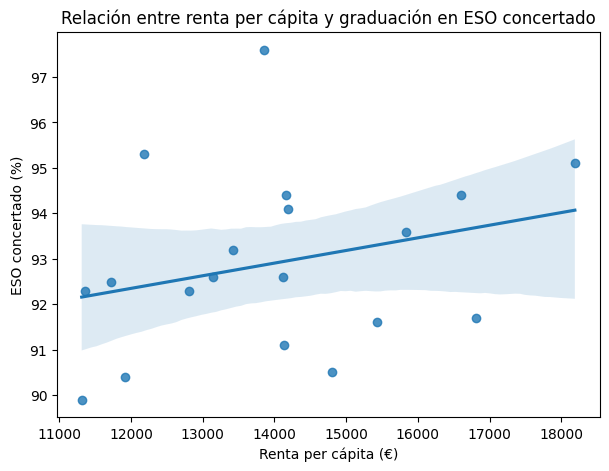

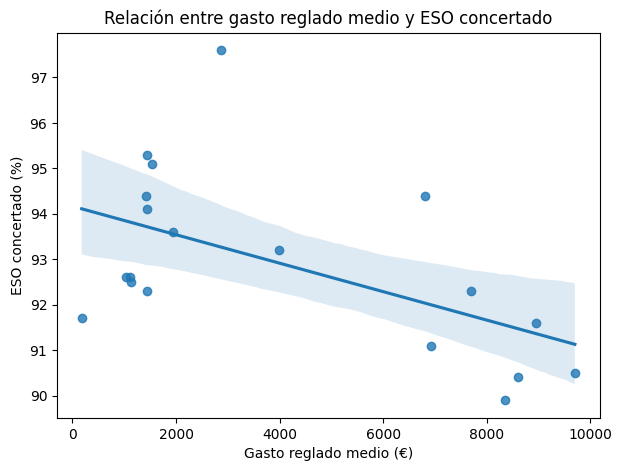

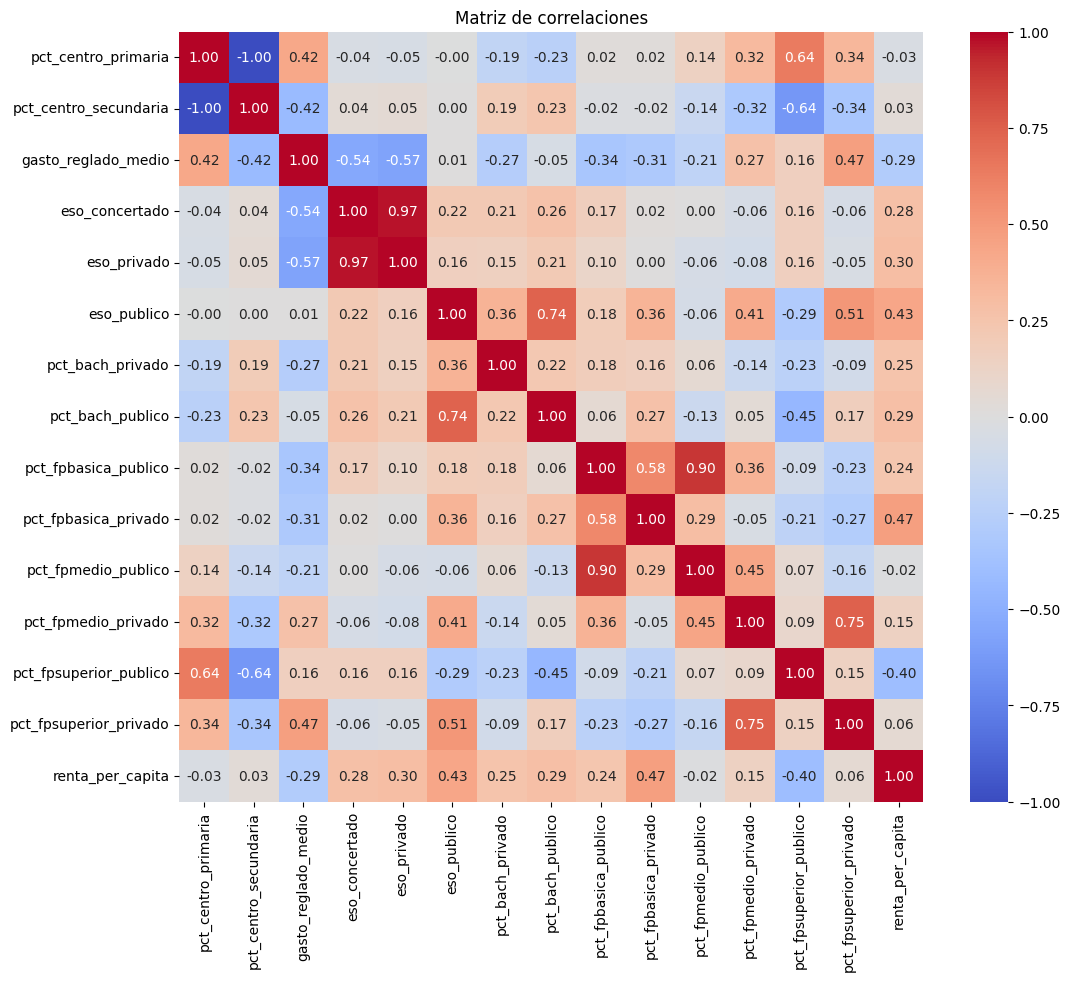

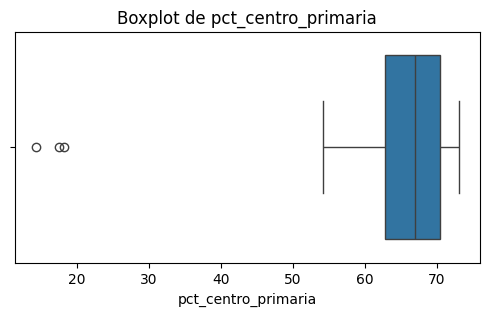

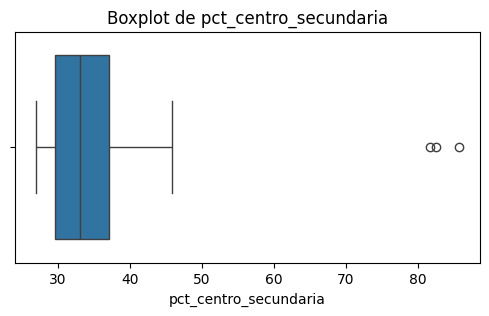

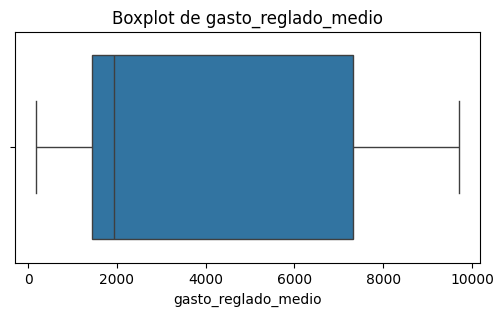

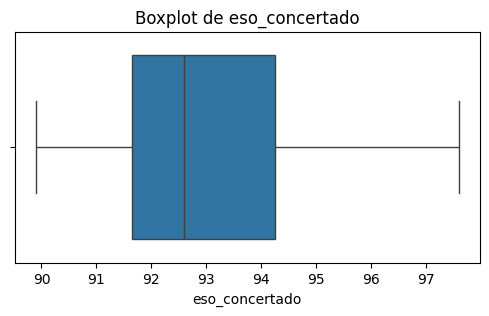

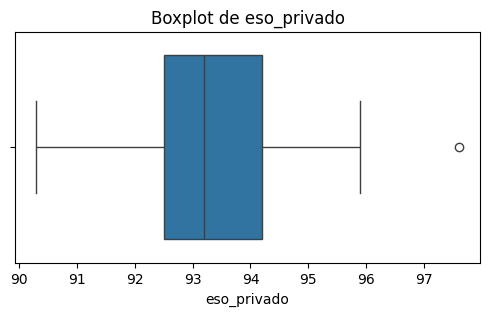

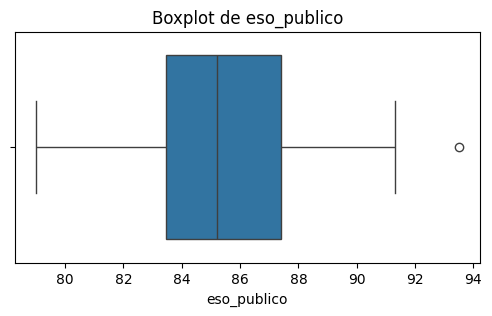

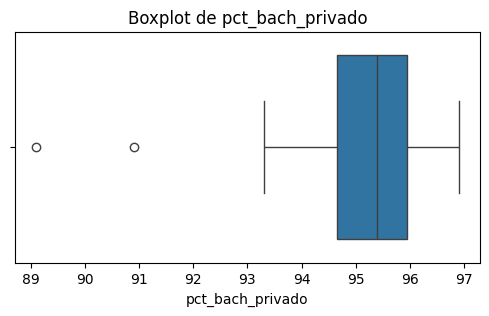

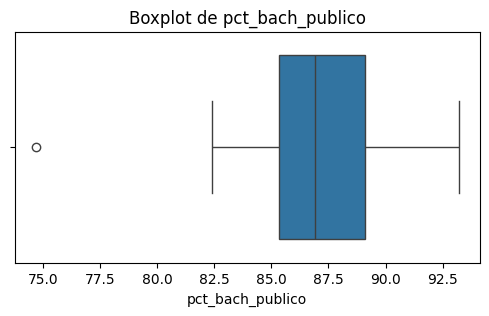

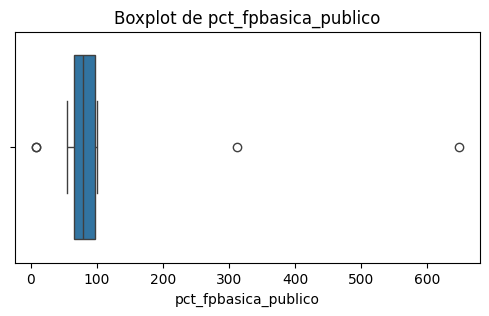

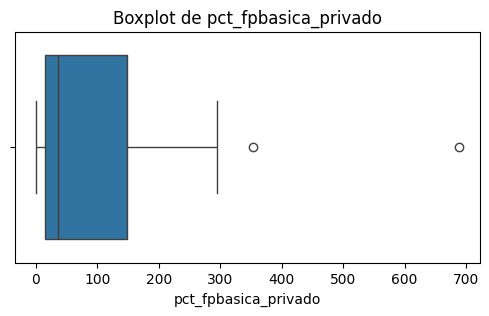

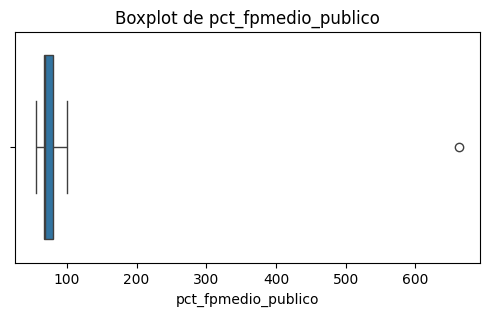

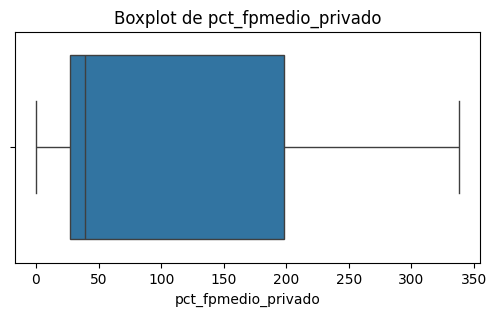

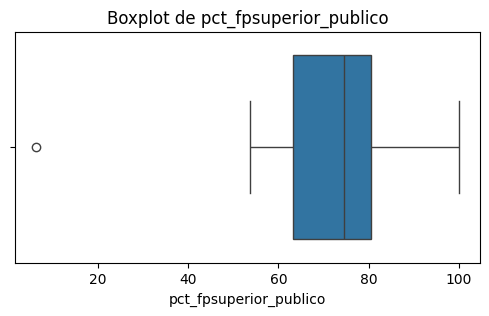

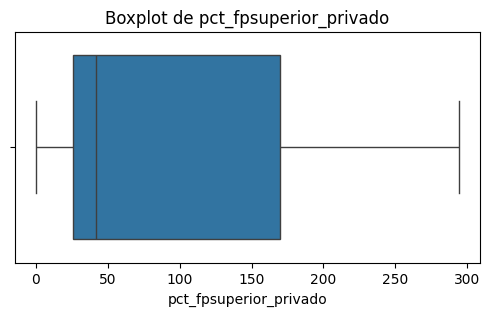

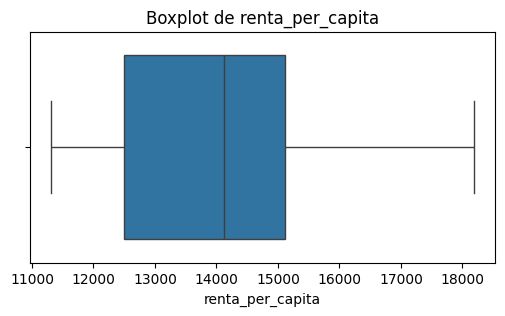

,variable,n_outliers,%_outliers
8,pct_fpbasica_publico,4,21.05
1,pct_centro_secundaria,3,15.79
0,pct_centro_primaria,3,15.79
9,pct_fpbasica_privado,2,10.53
6,pct_bach_privado,2,10.53
5,eso_publico,1,5.26
4,eso_privado,1,5.26
12,pct_fpsuperior_publico,1,5.26
10,pct_fpmedio_publico,1,5.26
7,pct_bach_publico,1,5.26


In [120]:
# 1. VALIDACIÓN DEL DATASET
# 1.1 Obtenemos su dimensión

print("Dimensiones:", BaseFinal2.shape)

# 1.2 Verificamos duplicados

print("Duplicados:",BaseFinal2.duplicated().sum())

# 1.3 Tipos de datos

BaseFinal2.dtypes

# 1.4 Comprobamos los valores nulos

(BaseFinal2.isnull().sum() / len(BaseFinal2)) * 100

# 2. ANÁLISIS DESCRIPTIVO
# 2.1 Seleccionamos las variables numéricas (todas menos las de ccaa)

numericas = BaseFinal2.select_dtypes(include=["float64", "int64"]).columns

# 2.2 Calculamos los estadísticos descriptivos más relevantes y que nos proporcionan información

estadisticos = BaseFinal2[numericas].describe().T
estadisticos["mediana"] = BaseFinal2[numericas].median()
estadisticos["varianza"] = BaseFinal2[numericas].var()

display(estadisticos)

# 3. DISTRIBUCIÓN DE LAS VARIABLES NUMÉRICAS

for col in numericas:
    plt.figure(figsize=(6,4))
    sns.histplot(BaseFinal2[col], kde=True)
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()

# 4. ANÁLISIS POR CCAA
# 4.1 Ranking de las comunidades autónomas en función de la renta per capita (de mayor a menor)

BaseFinal2.sort_values("renta_per_capita").plot(
    x="ccaa",
    y="renta_per_capita",
    kind="barh",
    figsize=(8,6)
)
plt.title("Renta per cápita por CCAA")
plt.xlabel("Renta per cápita (€)")
plt.ylabel("Comunidad Autónoma")
plt.tight_layout()
plt.show()

# 4.2 Ranking de las comunidades autónomas en función del gasto medio en educación (de mayor a menor)

BaseFinal2.sort_values("gasto_reglado_medio").plot(
    x="ccaa",
    y="gasto_reglado_medio",
    kind="barh",
    figsize=(8,6),
    color="orange"
)
plt.title("Gasto reglado medio por CCAA")
plt.xlabel("Gasto reglado medio (€)")
plt.ylabel("Comunidad Autónoma")
plt.tight_layout()
plt.show()

# 4.3 Ranking de las comunidades autónomas que tienen más porcentaje de graduados de la ESO en centros públicos

BaseFinal2.sort_values("eso_publico").plot(
    x="ccaa",
    y="eso_publico",
    kind="barh",
    figsize=(8,6),
    color="green"
)
plt.title("Porcentaje de graduados en ESO en centros públicos por CCAA")
plt.xlabel("Porcentaje")
plt.ylabel("Comunidad Autónoma")
plt.tight_layout()
plt.show()

# 4.4 Ranking de las comunidades autónomas que tienen más porcentaje de graduados de la ESO en centros privados

BaseFinal2.sort_values("eso_privado").plot(
    x="ccaa",
    y="eso_privado",
    kind="barh",
    figsize=(8,6),
    color="yellow"
)
plt.title("Porcentaje de graduados en ESO en centros privados por CCAA")
plt.xlabel("Porcentaje")
plt.ylabel("Comunidad Autónoma")
plt.tight_layout()
plt.show()

# 4.5 Ranking de las comunidades autónomas que tienen más porcentaje de graduados de la ESO en centros concertados

BaseFinal2.sort_values("eso_concertado").plot(
    x="ccaa",
    y="eso_concertado",
    kind="barh",
    figsize=(8,6),
    color="pink"
)
plt.title("Porcentaje de graduados en ESO en centros concertados por CCAA")
plt.xlabel("Porcentaje")
plt.ylabel("Comunidad Autónoma")
plt.tight_layout()
plt.show()

# 5. RELACIONES ENTRE LAS VARIABLES
# 5.1 Relación entre renta y gasto educativo

plt.figure(figsize=(7,5))
sns.regplot(
    data=BaseFinal2,
    x="renta_per_capita",
    y="gasto_reglado_medio"
)
plt.title("Relación entre renta per cápita y gasto reglado medio")
plt.xlabel("Renta per cápita (€)")
plt.ylabel("Gasto reglado medio (€)")
plt.show()

# 5.2 Relación entre renta y ESO público

plt.figure(figsize=(7,5))
sns.regplot(
    data=BaseFinal2,
    x="renta_per_capita",
    y="eso_publico"
)
plt.title("Relación entre renta per cápita y graduación en ESO pública")
plt.xlabel("Renta per cápita (€)")
plt.ylabel("ESO público (%)")
plt.show()

# 5.3 Relación entre gasto y ESO público

plt.figure(figsize=(7,5))
sns.regplot(
    data=BaseFinal2,
    x="gasto_reglado_medio",
    y="eso_publico"
)
plt.title("Relación entre gasto reglado medio y ESO público")
plt.xlabel("Gasto reglado medio (€)")
plt.ylabel("ESO público (%)")
plt.show()

# 5.4 Relación entre renta y ESO privado

plt.figure(figsize=(7,5))
sns.regplot(
    data=BaseFinal2,
    x="renta_per_capita",
    y="eso_privado"
)
plt.title("Relación entre renta per cápita y graduación en ESO privado")
plt.xlabel("Renta per cápita (€)")
plt.ylabel("ESO privado (%)")
plt.show()

# 5.5 Relación entre gasto y ESO privado

plt.figure(figsize=(7,5))
sns.regplot(
    data=BaseFinal2,
    x="gasto_reglado_medio",
    y="eso_privado"
)
plt.title("Relación entre gasto reglado medio y ESO privado")
plt.xlabel("Gasto reglado medio (€)")
plt.ylabel("ESO privado (%)")
plt.show()

# 5.6 Relación entre renta y ESO concertado

plt.figure(figsize=(7,5))
sns.regplot(
    data=BaseFinal2,
    x="renta_per_capita",
    y="eso_concertado"
)
plt.title("Relación entre renta per cápita y graduación en ESO concertado")
plt.xlabel("Renta per cápita (€)")
plt.ylabel("ESO concertado (%)")
plt.show()

# 5.7 Relación entre gasto y ESO concertado

plt.figure(figsize=(7,5))
sns.regplot(
    data=BaseFinal2,
    x="gasto_reglado_medio",
    y="eso_concertado"
)
plt.title("Relación entre gasto reglado medio y ESO concertado")
plt.xlabel("Gasto reglado medio (€)")
plt.ylabel("ESO concertado (%)")
plt.show()

# 6. ESTUDIAMOS LA CORRELACIÓN

correlacion = BaseFinal2[numericas].corr()

plt.figure(figsize=(12,10))
sns.heatmap(
    correlacion,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)
plt.title("Matriz de correlaciones")
plt.show()

# 7. ANALIZAMOS LOS POSIBLES OUTLIERS
# 7.1 Boxplots individuales

for col in numericas:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=BaseFinal2[col])
    plt.title(f"Boxplot de {col}")
    plt.show()

# 7.2 Detección formal de outliers

def detectar_outliers_iqr(df, columnas):            # Creamos una función para detectar los outliers
    resultados = []

    for col in columnas:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1                               # Fórmula del rango intercuartílico

        limite_inferior = Q1 - 1.5 * IQR            # < a esto se le considera outlier
        limite_superior = Q3 + 1.5 * IQR            # > a esto se le considera outlier

        n_outliers = ((df[col] < limite_inferior) | (df[col] > limite_superior)).sum()
        pct_outliers = (n_outliers / len(df)) * 100

        resultados.append({
            "variable": col,
            "n_outliers": n_outliers,
            "%_outliers": round(pct_outliers, 2)
        })

    return pd.DataFrame(resultados).sort_values("%_outliers", ascending=False)

# Visualizamos los outliers en una tabla

tabla_outliers = detectar_outliers_iqr(BaseFinal2, numericas)

display(tabla_outliers)
